# Convergence criteria
In this tutorial we will run a multiphysics simulation consisting of fully coupled single phase flow and mechanics. We present different ways of using convergence criteria. We differentiate between utilizing Euclidean norms for the full algebraic vectors occuring during iteration and Lebesgue norms that take into account the single sub-physics. In addition, we compare absolute and relative criteria.

The examples here are based on those in the [Poromechanics tutorial](./poromechanics.ipynb). Yet, we use looser tolerances to better dive into the differences of the convergence criteria.

# Poromechanics model

We redefine the same model as in the poromechanics tutorial. See [poromechanics tutorial](./poromechanics.ipynb) for explanations. The only difference is the use of slightly different material parameters inducing a more notable disparity between the scaling in the displacement and pressure variables.

In [1]:
import porepy as pp
from porepy.applications.md_grids.model_geometries import (
    SquareDomainOrthogonalFractures,
)
import numpy as np

In [2]:
class BodyForceMixin:
    nd: int
    """Ambient dimension."""

    units: pp.Units

    solid: pp.SolidConstants

    def body_force(self, subdomains: list[pp.Grid]) -> pp.ad.Operator:
        units = self.units
        vals = []
        for sd in subdomains:
            data = np.zeros((sd.num_cells, self.nd))

            # We add the source only to the 2D domain and not the fracture.
            if sd.dim == 2:
                # Selecting central cells
                cell_centers = sd.cell_centers
                indices = (
                    (cell_centers[0] > (0.3 / units.m))
                    & (cell_centers[0] < (0.7 / units.m))
                    & (cell_centers[1] > (0.3 / units.m))
                    & (cell_centers[1] < (0.7 / units.m))
                )

                acceleration = self.units.convert_units(-9.8, "m * s^-2")
                force = self.solid.density * acceleration
                data[indices, 1] = force * sd.cell_volumes[indices]

            vals.append(data)
        return pp.ad.DenseArray(np.concatenate(vals).ravel(), "body_force")

In [3]:
class PressureSourceBC:
    def bc_type_darcy_flux(self, sd: pp.Grid) -> pp.BoundaryCondition:
        """Assign Dirichlet boundary condition to the north boundary and Neumann
        everywhere else.

        """
        domain_sides = self.domain_boundary_sides(sd)
        bc = pp.BoundaryCondition(sd, domain_sides.north, "dir")
        return bc

    def fluid_source(self, subdomains: list[pp.Grid]) -> pp.ad.Operator:
        """Assign fracture source."""
        # Retrieve internal sources (jump in mortar fluxes) from the base class
        internal_sources: pp.ad.Operator = super().fluid_source(subdomains)

        # Retrieve external (integrated) sources from the exact solution.
        values = []
        src_value: float = self.units.convert_units(0.1, "kg * m^-3 * s^-1")
        for sd in subdomains:
            if sd.dim == self.mdg.dim_max():
                values.append(np.zeros(sd.num_cells))
            else:
                values.append(np.ones(sd.num_cells) * src_value)

        external_sources = pp.wrap_as_dense_ad_array(np.concatenate(values))

        # Add up both contributions
        source = internal_sources + external_sources
        source.set_name("fluid sources")

        return source

We redefine the poromechanics model, called PoromechanicsSourceBC in the poromechanics tutorial.

In [4]:
class Model(
    PressureSourceBC,
    BodyForceMixin,
    SquareDomainOrthogonalFractures,
    pp.Poromechanics,
):
    """Adding geometry, boundary conditions and source to the default model."""

    def meshing_arguments(self) -> dict:
        cell_size = self.units.convert_units(0.1, "m")
        return {"cell_size": cell_size}

We define two instantiations of the `Model`. Their difference will lie in disparate sets of solver parameters.

In [5]:
model = Model({"solver_statistics_file_name": "solver_statistics.json"})
multi_norm_model = Model({"solver_statistics_file_name": "multiphysics_norm_solver_statistics.json"})

## Convergence criteria
Convergence criteria are defined as part of the solver parameters. We distinguish between criteria to define convergence and divergence. There exist conceptually two different ways for defining these. By default, one can control absolute and relative criteria for increments and residuals to declare convergence. At the same time, divergence is invoked in the case of exceeding number of nonlinear iterations, exceeding norms for increments and residuals, as well as the occurrence of `nan`. To control these default criteria it is sufficient to define solver parameters (here unused but equivalent with the advanced setup concluded below):

In [6]:
solver_parameters_to_steer_convergence_criteria = {
    "nl_metric": pp.EuclideanMetric(), # metric to measure norms of increments and residuals
    "nl_convergence_inc_atol": 1e-2, # absolute tolerance on increments
    "nl_convergence_res_atol": 1e-2, # absolute tolerance on residuals
    "nl_convergence_inc_rtol": np.inf, # (disabled) relative tolerance on increments
    "nl_convergence_res_rtol": np.inf, # (disabled) relative tolerance on residuals
    "nl_divergence_inc_atol": np.inf, # (disabled) absolute tolerance on increments
    "nl_divergence_res_atol": np.inf, # (disabled) absolute tolerance on residuals
    "nl_max_iterations": 25, # maximum number of nonlinear iterations
}

One can also define custom convergence and divergence criteria and assign these directly through the solver parameters, which will overwrite the default criteria. The idea is to provide an arbitrary set of criteria, here provided as dictionary, where the keywords can be chosen arbitrarily and only will be reused during logging and storing of the `pp.SolverStatistics`. Various types of checks are available. Convergence will be only declared if all criteria are satisfied, while divergence is declared if merely one of these flags divergence. To mimick the above use of absolute criteria and the standard check of exceeding iteration as well as the obligatory `nan` check, we define:

In [7]:
solver_params_with_euclidean_norms = {
    "nl_convergence_criteria": {
        "inc_abs": pp.IncrementBasedAbsoluteCriterion(
            tol=1e-2, metric=pp.EuclideanMetric()
        ),
        "res_abs": pp.ResidualBasedAbsoluteCriterion(
            tol=1e-2, metric=pp.EuclideanMetric()
        ),
    },
    "nl_divergence_criteria": {
        "max_iter": pp.MaxIterationsCriterion(max_iterations=25),
        "inc_nan": pp.IncrementBasedNanCriterion(),
        "res_nan": pp.ResidualBasedNanCriterion(),
    },
}

We define analogous criteria yet based on norms that split single variables and equations within the multiphysics context. These require an instance of the model to correctly map bewteen linear algebra and correct DOFs.

In [8]:
solver_params_with_multiphysics_norm = {
    "nl_convergence_criteria": {
        "inc_abs": pp.IncrementBasedAbsoluteCriterion(
            tol=1e-2, metric=pp.VariableBasedEuclideanMetric(multi_norm_model)
        ),
        "res_abs": pp.ResidualBasedAbsoluteCriterion(
            tol=1e-2, metric=pp.EquationBasedEuclideanMetric(multi_norm_model)
        ),
    },
    "nl_divergence_criteria": {
        "max_iter": pp.MaxIterationsCriterion(max_iterations=25),
        "inc_nan": pp.IncrementBasedNanCriterion(),
        "res_nan": pp.ResidualBasedNanCriterion(),
    },
}

We are ready to run the models with different options.

In [9]:
pp.run_time_dependent_model(model, solver_params_with_euclidean_norms)
pp.run_time_dependent_model(multi_norm_model, solver_params_with_multiphysics_norm)

C:\Users\jbo062\src\porepy\src\porepy\models\solution_strategy.py:804: UserWarning: PyPardiso could not be imported,
                    falling back on scipy.sparse.linalg.spsolve
  warnings.warn(


We compare the solutions in the eye-norm (there is no obvious difference).

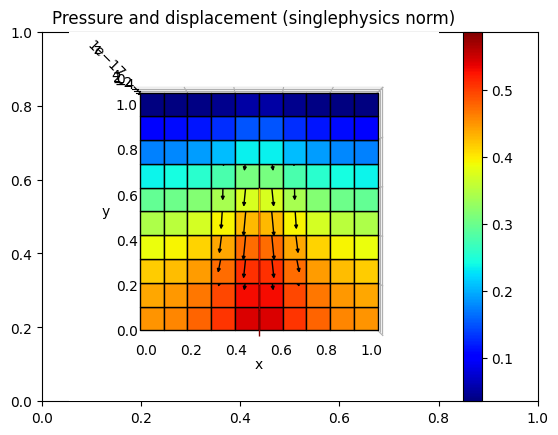

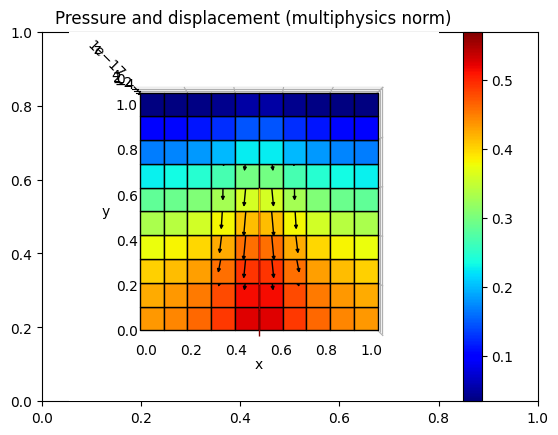

In [10]:
pp.plot_grid(
    model.mdg,
    cell_value=model.pressure_variable,
    vector_value=model.displacement_variable,
    figsize=(10, 8),
    title="Pressure and displacement (singlephysics norm)",
)

pp.plot_grid(
    multi_norm_model.mdg,
    cell_value=multi_norm_model.pressure_variable,
    vector_value=multi_norm_model.displacement_variable,
    figsize=(10, 8),
    title="Pressure and displacement (multiphysics norm)",
)

We compare the number of nonlinear iterations (now there is a difference).

In [11]:
# Compare the number of iterations for the two models
print(f"Number of iterations (plain model): {model.nonlinear_solver_statistics.num_iterations}")
print(f"Number of iterations (multi-physics criteria): {multi_norm_model.nonlinear_solver_statistics.num_iterations}")

Number of iterations (plain model): 2
Number of iterations (multi-physics criteria): 4


Let's dive into the logged custom data of the multi norm model. Essentially the two models are the same, the latter has simply used two extra iterations.

In [12]:
import pprint
pprint.pprint(model.nonlinear_solver_statistics, width=80, depth=3)

NonlinearSolverAndTimeStatistics(index=0,
                                 path=WindowsPath('visualization/solver_statistics.json'),
                                 num_cells={'1': 10, '2': 100},
                                 num_domains={'1': 1, '2': 1},
                                 simulation_status=<SimulationStatus.SUCCESSFUL: 'successful'>,
                                 simulation_status_history=[<SimulationStatus.SUCCESSFUL: 'successful'>],
                                 custom_data={},
                                 num_iterations=2,
                                 num_iterations_history=[2],
                                 convergence_status={'inc_abs': [<ConvergenceStatus.NOT_CONVERGED: 'not_converged'>,
                                                                 <ConvergenceStatus.CONVERGED: 'converged'>],
                                                     'inc_nan': [<ConvergenceStatus.CONVERGED: 'converged'>,
                                         

In [13]:
pprint.pprint(multi_norm_model.nonlinear_solver_statistics, width=80, depth=3)

NonlinearSolverAndTimeStatistics(index=0,
                                 path=WindowsPath('visualization/multiphysics_norm_solver_statistics.json'),
                                 num_cells={'1': 10, '2': 100},
                                 num_domains={'1': 1, '2': 1},
                                 simulation_status=<SimulationStatus.SUCCESSFUL: 'successful'>,
                                 simulation_status_history=[<SimulationStatus.SUCCESSFUL: 'successful'>],
                                 custom_data={},
                                 num_iterations=4,
                                 num_iterations_history=[4],
                                 convergence_status={'inc_abs': [<ConvergenceStatus.NOT_CONVERGED: 'not_converged'>,
                                                                 <ConvergenceStatus.NOT_CONVERGED: 'not_converged'>,
                                                                 <ConvergenceStatus.NOT_CONVERGED: 'not_converged'>,
        

To conclude, in the above comparison, the single-physics criteria do not see a great difference in continuing for two more nonlinear iterations, whereas the multi-physics norms are sensitive to the single components and request further iteration. 

Diving a bit further into the details, it is mostly interface quantities which do not get seen by a global approach, as they get lumped together with the rest, and if much fewer interface cells are present, these get overseen by the global Euclidean norm. By splitting, and checking the convergence on each, we typically get better control on the convergence of the different sub-physics.

## Lebesgue norms (in constrast to Euclidean norms)
The present example has a regular grid. Thus, there is no strong need to take into account the cell sizes as a weight in the norm. This can drastically change, when considering multi-fractured domains with tiny cells close to multiple fractures intersecting. Then, the Euclidean norms, which do not see any scaling are not sensitive to the size of the cells and naturally count in tiny cells in the same degree as large cells. Also in grid refinement studies (although the Euclidean norms in PorePy are scaled by the overall size of the algebraic problem), the use of cell-weighted norms is size-invariant. 

In order to activate Lebesgue norms, we change the metric used in the single criteria.

In [14]:
multi_lebesgue_model = Model()
solver_params_with_lebesgue_norm = {
    "nl_convergence_criteria": {
        "inc_abs": pp.IncrementBasedAbsoluteCriterion(
            tol=1e-2, metric=pp.VariableBasedLebesgueMetric(multi_lebesgue_model)
        ),
        "res_abs": pp.ResidualBasedAbsoluteCriterion(
            tol=1e-2, metric=pp.EquationBasedLebesgueMetric(multi_lebesgue_model)
        ),
    },
    "nl_divergence_criteria": {
        "max_iter": pp.MaxIterationsCriterion(max_iterations=25),
        "inc_nan": pp.IncrementBasedNanCriterion(),
        "res_nan": pp.ResidualBasedNanCriterion(),
    },
}
pp.run_time_dependent_model(multi_lebesgue_model, solver_params_with_lebesgue_norm)
print(f"Number of iterations (multi-physics Lebesgue criteria): {multi_lebesgue_model.nonlinear_solver_statistics.num_iterations}")

Number of iterations (multi-physics Lebesgue criteria): 4


## Relative convergence criteria
In some situations (not here actually), it is necessary to use relative criteria. Such can be activated by providing additional solver parameters. We skew the units to make the point that there.

In [15]:
params = {
    "units": pp.Units(m=1, kg=1e-4)
}

We redefine two models.

In [16]:
multi_norm_model_with_skewed_units = Model(params)
multi_norm_model_with_skewed_units_and_relative_criteria = Model(params)

For a direct comparison, we use the previous set of variable and equation based criteria (using absolute criteria) and a new one based only on relative criteria. We use the opportunity to explicitly define divergence criteria based on exceeding norms of increments and residuals. These are not activated here, but serve only an educational purpose.

In [17]:
solver_params_with_relative_criteria = {
    "nl_convergence_criteria": {
        "inc_rel": pp.IncrementBasedRelativeCriterion(
            tol=1e-2, metric=pp.VariableBasedEuclideanMetric(multi_norm_model_with_skewed_units_and_relative_criteria)
        ),
        "res_rel": pp.ResidualBasedRelativeCriterion(
            tol=1e-2, metric=pp.EquationBasedEuclideanMetric(multi_norm_model_with_skewed_units_and_relative_criteria  )
        ),
    },
    "nl_divergence_criteria": {
        "max_iter": pp.MaxIterationsCriterion(max_iterations=25),
        "inc_nan": pp.IncrementBasedNanCriterion(),
        "res_nan": pp.ResidualBasedNanCriterion(),
        "inc_div": pp.IncrementBasedRelativeDivergenceCriterion(
            tol=1e20, metric=pp.EuclideanMetric()
        ),
        "res_div": pp.ResidualBasedRelativeDivergenceCriterion(
            tol=1e20, metric=pp.EuclideanMetric()
        ),
    },
}

pp.run_time_dependent_model(multi_norm_model_with_skewed_units, solver_params_with_multiphysics_norm)
pp.run_time_dependent_model(multi_norm_model_with_skewed_units_and_relative_criteria, solver_params_with_relative_criteria)

print(f"Number of iterations (restarted model with skewed units and absolute criteria): {multi_norm_model_with_skewed_units.nonlinear_solver_statistics.num_iterations}")
print(f"Number of iterations (restarted model with skewed units and relative criteria): {multi_norm_model_with_skewed_units_and_relative_criteria.nonlinear_solver_statistics.num_iterations}")

Number of iterations (restarted model with skewed units and absolute criteria): 6
Number of iterations (restarted model with skewed units and relative criteria): 4


We see that the absolute criteria required an extra iteration here. Let's checkout the history of the residual norms. Indeed, the absolute criteria track a relative decrease of about 1e-6, but since the `kg` unit is scaled, some of the equations are not scaled on the order of 1 (as for the uniform parameters above). E.g., the pressure is scaled aqay from 1, or the momentum equation.

In [18]:
print("Residual history for absolute criteria:")
pprint.pprint(multi_norm_model_with_skewed_units.nonlinear_solver_statistics.convergence_info, width=80, depth=3)

Residual history for absolute criteria:
{'inc_abs': {'contact_traction': [np.float64(0.730494783112916),
                                  np.float64(0.03156134520372667),
                                  np.float64(0.00039129492724502543),
                                  np.float64(2.0919817482938632e-05),
                                  np.float64(3.8355023217913784e-07),
                                  np.float64(1.3615826900197362e-08)],
             'interface_darcy_flux': [np.float64(423.7975309232214),
                                      np.float64(16.2957162620041),
                                      np.float64(16.93505296499759),
                                      np.float64(0.6931622089435834),
                                      np.float64(0.028680012784094565),
                                      np.float64(0.0010608840182627483)],
             'pressure': [np.float64(3589.2491688458713),
                          np.float64(12.202995414288841),
         

As comparison, we check the model run using the relative criteria. 

In [19]:
print("\nResidual history for relative criteria:")
pprint.pprint(multi_norm_model_with_skewed_units_and_relative_criteria.nonlinear_solver_statistics.convergence_info, width=80, depth=3)


Residual history for relative criteria:
{'inc_rel': {'contact_traction': [np.float64(22.038979307533637),
                                  np.float64(0.9522036980178393),
                                  np.float64(0.011805342083275333),
                                  np.float64(0.0006311495102800728)],
             'interface_darcy_flux': [np.float64(1.0),
                                      np.float64(0.03845165455896996),
                                      np.float64(0.03996024452550593),
                                      np.float64(0.0016355975633778816)],
             'pressure': [np.float64(1.0),
                          np.float64(0.0033998741352951915),
                          np.float64(0.03406882404653714),
                          np.float64(0.0008204525858766641)],
             'u': [np.float64(1.0),
                   np.float64(0.11539966234264123),
                   np.float64(0.007519827857122082),
                   np.float64(0.00023477491059890884

## Solver statistics
As a bonus, let us briefly present the overall data logged by the solver statistics object. As the problem is time dependent, and nonlinear, relevant parameters are tracked.

In [20]:
import pprint
for key, value in multi_norm_model.nonlinear_solver_statistics.__dict__.items():
    print(f"Key: {key}")
    pprint.pprint(value, width=80, depth=3)
    print()

Key: index
0

Key: path
WindowsPath('visualization/multiphysics_norm_solver_statistics.json')

Key: num_cells
{'1': 10, '2': 100}

Key: num_domains
{'1': 1, '2': 1}

Key: simulation_status
<SimulationStatus.SUCCESSFUL: 'successful'>

Key: simulation_status_history
[<SimulationStatus.SUCCESSFUL: 'successful'>]

Key: custom_data
{}

Key: num_iterations
4

Key: num_iterations_history
[4]

Key: convergence_status
{'inc_abs': [<ConvergenceStatus.NOT_CONVERGED: 'not_converged'>,
             <ConvergenceStatus.NOT_CONVERGED: 'not_converged'>,
             <ConvergenceStatus.NOT_CONVERGED: 'not_converged'>,
             <ConvergenceStatus.CONVERGED: 'converged'>],
 'inc_nan': [<ConvergenceStatus.CONVERGED: 'converged'>,
             <ConvergenceStatus.CONVERGED: 'converged'>,
             <ConvergenceStatus.CONVERGED: 'converged'>,
             <ConvergenceStatus.CONVERGED: 'converged'>],
 'max_iter': [<ConvergenceStatus.CONVERGED: 'converged'>,
              <ConvergenceStatus.CONVERGED: 'co

## Logging custom data
The `pp.SolverStatistics` object allows for simple exporting of sparse quantities in addition to convergence metric. For this, e.g., we can define an additional mixin, which allows to log norms over the course of the nonlinear iterations. For this, one needs to call the method `log_custom_data` of the `nonlinear_solver_statistics`. Two modes can be chosen, either `append=True` which will collect data over the course of iterations, while `append=False` simply tracks a single quantity for an entire time step (e.g. useful to track characteristic quantities).

In [21]:
class CustomStatisticsLogger:
    """Logs custom norms during the nonlinear iterations."""

    nonlinear_solver_statistics: pp.NonlinearSolverStatistics

    def after_nonlinear_iteration(self, nonlinear_increment: np.ndarray):

        # Basic shift of iteration and update approximation.
        super().after_nonlinear_iteration(nonlinear_increment)

        # Compute plain norms of residual and increment.
        residual = self.equation_system.assemble(evaluate_jacobian=False)
        increment_norms = np.linalg.norm(nonlinear_increment)
        residual_norms = np.linalg.norm(residual)

        # Log custom data.
        self.nonlinear_solver_statistics.log_custom_data(
            append=True,
            **{"increment_norms": increment_norms,"residual_norms": residual_norms},
        )
        

# What we have explored
We took a deep dive into the convergence behavior of the poromechanics model, already presented in the [poromechanics tutorial](./poromechanics.ipynb). We explored the possibilities to define different convergence cirteria, differing in the composition but also the used norms for measuring increments and residuals, as well as absolute and relative criteria. This interface allows for problem-specific extension. User-defined criteria only need to follow the provided structure of `pp.ConvergenceCriterion` and `pp.DivergenceCriterion`.